# Generate Dataset Mentah (Raw Data) — Procurement Pabrik Olahan Susu

**Tujuan:** membuat data mentah sintetis dari sistem operasional (sebelum ETL) yang nanti diolah
menjadi star schema di folder `dataset_procurement_susu` (FIX.zip).

**Acuan data:** master vendor, produk, dan kontrak diambil dari CSV di FIX.zip. Distribusi qty & harga
dipelajari dari `fact_purchase_order.csv`, jadi data baru tetap mirip dengan dataset aslinya.

**Tabel sumber yang dihasilkan**

| No | Tabel | Sistem sumber | Isi |
|---|---|---|---|
| 1 | `src_vendor.csv` | ERP – master vendor | data vendor terkini |
| 2 | `src_product.csv` | ERP – master produk | data produk terkini + harga standar |
| 3 | `src_contract.csv` | Contract Management | kontrak vendor–produk |
| 4 | `src_purchase_order.csv` | ERP – Purchasing | **10.000 baris transaksi PO** |
| 5 | `src_goods_receipt.csv` | Gudang & QC | hasil QC & penerimaan barang |
| 6 | `src_change_log.csv` | Audit log semua sistem | riwayat perubahan (bahan SCD) |

**Langkah:** (1) baca dataset acuan → (2) master data + Faker → (3) kontrak → (4) transaksi PO →
(5) penerimaan & QC → (6) skenario SCD → (7) outlier → (8) simpan & cek.

## 0. Import library & pengaturan
Letakkan folder `dataset_procurement_susu/` (isi FIX.zip) di folder yang sama dengan notebook ini.

In [1]:
# !pip install faker pandas numpy matplotlib
import os
import numpy as np
import pandas as pd
from faker import Faker
import matplotlib.pyplot as plt

SEED = 42                                   # seed agar hasil selalu sama tiap dijalankan
rng = np.random.default_rng(SEED)
fake = Faker('id_ID')                       # Faker lokal Indonesia
Faker.seed(SEED)

FIX_DIR = 'dataset_procurement_susu'        # folder dataset acuan (FIX.zip)
OUT_DIR = 'raw_data'                        # folder output data mentah
os.makedirs(OUT_DIR, exist_ok=True)

TGL_MULAI = pd.Timestamp('2024-01-01')
TGL_AKHIR = pd.Timestamp('2026-09-25')      # tanggal data diekstrak dari sistem
JUMLAH_BARIS = 10_000                       # target baris transaksi PO

## 1. Baca dataset acuan (FIX.zip)

In [2]:
dim_vendor   = pd.read_csv(f'{FIX_DIR}/dim_vendor.csv')
dim_product  = pd.read_csv(f'{FIX_DIR}/dim_product.csv')
dim_contract = pd.read_csv(f'{FIX_DIR}/dim_contract.csv')
fact         = pd.read_csv(f'{FIX_DIR}/fact_purchase_order.csv')

# Ubah surrogate key (angka) menjadi natural key (VND-xxx, PRD-xxx, CTR-xxx) seperti di sistem sumber
fact = (fact
        .merge(dim_vendor[['vendor_key', 'vendor_id']], on='vendor_key')
        .merge(dim_product[['product_key', 'product_id', 'product_type']], on='product_key')
        .merge(dim_contract[['contract_key', 'contract_id']], on='contract_key'))
print('Baris fact acuan:', len(fact))
dim_vendor.head()

Baris fact acuan: 14828


,vendor_key,vendor_id,vendor_name,vendor_category,city,region
0,1,VND-001,Koperasi Peternak Sapi Perah Merapi Makmur,Koperasi Susu,Boyolali,Jawa Tengah
1,2,VND-002,KUD Sari Mulya Pangalengan,Koperasi Susu,Bandung,Jawa Barat
2,3,VND-003,Koperasi Susu Lembah Tengger,Koperasi Susu,Pasuruan,Jawa Timur
3,4,VND-004,PT Peternakan Sapi Nusa Hijau,Peternakan Sapi Perah,Malang,Jawa Timur
4,5,VND-005,CV Lembang Dairy Farm,Peternakan Sapi Perah,Bandung Barat,Jawa Barat


## 2. Generator custom: profil distribusi dari data acuan
Untuk tiap produk dihitung **median qty**, **sebaran qty (sigma log)**, dan **median harga**.
Qty baru nanti diambil dari distribusi **lognormal** (miring ke kanan, cocok untuk qty pembelian).
Bobot vendor dan pasangan vendor–produk juga diambil dari frekuensi di data acuan.

In [3]:
profil_produk = fact.groupby('product_id').agg(
    qty_median   = ('quantity_ordered', 'median'),
    qty_sigma    = ('quantity_ordered', lambda x: np.log(x).std()),
    harga_median = ('unit_price', 'median'),
).reset_index().merge(dim_product[['product_id', 'product_type', 'unit_of_measure']], on='product_id')

bobot_vendor  = fact.groupby('vendor_id').order_id.nunique()
bobot_vendor  = bobot_vendor / bobot_vendor.sum()                 # peluang vendor mendapat PO
produk_vendor = fact.groupby('vendor_id').product_id.unique().to_dict()   # produk yang dijual tiap vendor

profil_produk.round(2)

,product_id,qty_median,qty_sigma,harga_median,product_type,unit_of_measure
0,PRD-001,16193.67,0.55,7401.67,Bahan Baku Utama,Liter
1,PRD-002,13323.95,0.57,6941.84,Bahan Baku Utama,Liter
2,PRD-003,2137.16,0.57,39209.44,Bahan Baku Utama,Liter
3,PRD-004,110.00,0.58,372674.40,Bahan Pembantu,Sachet
4,PRD-005,60.00,0.65,432052.60,Bahan Pembantu,Sachet
5,PRD-006,31.61,0.63,1262534.00,Bahan Pembantu,Liter
6,PRD-007,1500.00,0.66,9640.00,Bahan Pembantu,Kg
7,PRD-008,729.00,0.68,8398.60,Bahan Pembantu,Kg
8,PRD-009,36.75,0.70,280550.40,Bahan Pembantu,Liter
9,PRD-010,107000.00,0.65,1300.00,Material Kemasan,Pcs


## 3. Master data vendor & produk (+ Faker)
Kolom dari dataset acuan dilengkapi data kontak buatan Faker (nama PIC, telepon, email, alamat).
Produk diberi `standard_price` awal (harga standar ERP) yang nanti berubah tiap tahun (skenario SCD 2).

In [4]:
src_vendor = dim_vendor.drop(columns='vendor_key').rename(columns={'region': 'province'})
src_vendor['contact_person'] = [fake.name() for _ in range(len(src_vendor))]
src_vendor['phone']          = [fake.phone_number() for _ in range(len(src_vendor))]
src_vendor['email']          = ['purchasing@' + n.lower().replace('pt ', '').replace('cv ', '').replace(' ', '')[:15] + '.co.id'
                                for n in src_vendor.vendor_name]
src_vendor['address']        = [fake.street_address() for _ in range(len(src_vendor))]
src_vendor['created_at']     = pd.Timestamp('2023-12-01')
src_vendor['updated_at']     = pd.Timestamp('2023-12-01')

src_product = dim_product.drop(columns='product_key').rename(columns={'product_type': 'product_category'})
src_product['standard_price'] = (src_product.product_id.map(profil_produk.set_index('product_id').harga_median) * 0.97).round(2)
src_product['created_at'] = pd.Timestamp('2023-12-01')
src_product['updated_at'] = pd.Timestamp('2023-12-01')

# daftar staf internal (Faker) untuk kolom created_by / inspector
BUYER     = [fake.name() for _ in range(5)]
INSPEKTUR = [fake.name() for _ in range(4)]
src_vendor.head(3)

,vendor_id,vendor_name,vendor_category,city,province,contact_person,phone,email,address,created_at,updated_at
0,VND-001,Koperasi Peternak Sapi Perah Merapi Makmur,Koperasi Susu,Boyolali,Jawa Tengah,"Balidin Dongoran, S.T.",+62 (0131) 647-5255,purchasing@koperasipeterna.co.id,Gang Peta No. 87,2023-12-01,2023-12-01
1,VND-002,KUD Sari Mulya Pangalengan,Koperasi Susu,Bandung,Jawa Barat,Darmana Mandala,+62-419-283-2764,purchasing@kudsarimulyapan.co.id,Gg. Lembong No. 980,2023-12-01,2023-12-01
2,VND-003,Koperasi Susu Lembah Tengger,Koperasi Susu,Pasuruan,Jawa Timur,"Ciaobella Wastuti, M.Pd",0835030564,purchasing@koperasisusulem.co.id,Jl. Indragiri No. 88,2023-12-01,2023-12-01


## 4. Kontrak (Contract Management)
Setiap kontrak di `dim_contract` dipasangkan ke vendor & produk yang memakainya di data acuan.
* Kontrak **2024** berlaku 1 Jan – 31 Des 2024.
* Kontrak **2025** berlaku 1 Jan – 31 Des 2025, lalu **diperpanjang lewat adendum** ke 2026 (dicatat di change log → SCD 3).
* `agreed_price` = median harga kontrak tersebut di data acuan.

In [5]:
kontrak = (fact[fact.contract_id != 'CTR-NONE']
           .groupby('contract_id')
           .agg(vendor_id=('vendor_id', 'first'), product_id=('product_id', 'first'), agreed_price=('unit_price', 'median'))
           .reset_index())
src_contract = dim_contract[dim_contract.contract_id != 'CTR-NONE'].drop(columns=['contract_key', 'is_active']).merge(kontrak, on='contract_id')
src_contract = src_contract.rename(columns={'max_quota_limit': 'quota_volume'})
src_contract['agreed_price'] = src_contract.agreed_price.round(2)
tahun = src_contract.contract_id.str[4:8]
src_contract['start_date'] = pd.to_datetime(tahun + '-01-01')
src_contract['end_date']   = pd.to_datetime(tahun + '-12-31')
src_contract['payment_term'] = rng.choice(['Net 30', 'Net 60', 'Net 90'], size=len(src_contract), p=[.5, .35, .15])
src_contract['signed_date']  = src_contract.start_date - pd.to_timedelta(rng.integers(10, 40, len(src_contract)), unit='D')

def cari_kontrak(vendor_id, product_id, tanggal):
    """Mengembalikan baris kontrak yang aktif pada tanggal tersebut, atau None (pembelian spot)."""
    k = src_contract[(src_contract.vendor_id == vendor_id) & (src_contract.product_id == product_id)
                     & (src_contract.start_date <= tanggal) & (src_contract.end_date >= tanggal)]
    return None if k.empty else k.iloc[0]

src_contract.head(3)

,contract_id,contract_type,price_agreement_type,quota_volume,sla_temperature_requirement,vendor_id,product_id,agreed_price,start_date,end_date,payment_term,signed_date
0,CTR-2024-001,SLA-Based Quality Contract,Harga Indeks Pasar,4039600.0,Rantai Dingin 2-4 °C,VND-001,PRD-001,7272.14,2024-01-01,2024-12-31,Net 60,2023-11-25
1,CTR-2025-002,SLA-Based Quality Contract,Harga Indeks Pasar,7991800.0,Rantai Dingin 2-4 °C,VND-001,PRD-001,7813.02,2025-01-01,2025-12-31,Net 30,2024-12-14
2,CTR-2024-003,SLA-Based Quality Contract,Harga Berjenjang (Tiered by Grade),3701100.0,Rantai Dingin 2-4 °C,VND-001,PRD-002,6615.00,2024-01-01,2024-12-31,Net 90,2023-12-09


## 5. Skenario SCD (perubahan master data)
Sistem sumber hanya menyimpan **nilai terbaru** di tabel master; nilai lama tercatat di `src_change_log`.
Dari log inilah proses ETL membentuk SCD.

| Tabel | Perubahan | Tipe SCD |
|---|---|---|
| vendor | koreksi nama (VND-002, VND-013), ganti PIC/telepon | 1 (timpa) |
| vendor | pindah kota/provinsi (VND-005, VND-011), ganti kategori (VND-012) | 2 (baris baru) |
| product | ganti nama (PRD-012) | 1 |
| product | reklasifikasi kategori (PRD-015), kenaikan `standard_price` tiap 1 Januari | 2 |
| contract | adendum perpanjangan `end_date` & perubahan `quota_volume` (kontrak 2025) | 3 (simpan nilai sebelumnya) |

In [6]:
change_log = []

def ubah(tabel, df, kolom_id, id_, kolom, nilai_baru, tanggal, alasan):
    """Mengubah nilai di tabel master DAN mencatat nilai lamanya ke change log."""
    tanggal = pd.Timestamp(tanggal)
    idx = df.index[df[kolom_id] == id_][0]
    change_log.append(dict(table_name=tabel, record_id=id_, column_name=kolom, old_value=df.at[idx, kolom],
                           new_value=nilai_baru, changed_at=tanggal, reason=alasan))
    df.at[idx, kolom] = nilai_baru
    if 'updated_at' in df.columns:
        df.at[idx, 'updated_at'] = max(df.at[idx, 'updated_at'], tanggal)

# ---- Vendor: SCD 1 ----
ubah('vendor', src_vendor, 'vendor_id', 'VND-002', 'vendor_name', 'KUD Sari Mulya Pangalengan Bandung', '2024-05-20', 'Koreksi nama badan usaha')
ubah('vendor', src_vendor, 'vendor_id', 'VND-013', 'vendor_name', 'PT Aseptika Kemasindo Tbk', '2025-11-10', 'Perusahaan menjadi Tbk')
for vid in rng.choice(src_vendor.vendor_id, size=5, replace=False):
    tgl = TGL_MULAI + pd.Timedelta(days=int(rng.integers(60, 950)))
    ubah('vendor', src_vendor, 'vendor_id', vid, 'contact_person', fake.name(), tgl, 'Pergantian PIC vendor')
    ubah('vendor', src_vendor, 'vendor_id', vid, 'phone', fake.phone_number(), tgl, 'Pergantian PIC vendor')
# ---- Vendor: SCD 2 ----
ubah('vendor', src_vendor, 'vendor_id', 'VND-005', 'city', 'Subang', '2025-03-01', 'Relokasi peternakan')
ubah('vendor', src_vendor, 'vendor_id', 'VND-011', 'city', 'Tuban', '2025-08-15', 'Relokasi gudang')
ubah('vendor', src_vendor, 'vendor_id', 'VND-011', 'province', 'Jawa Timur', '2025-08-15', 'Relokasi gudang')
ubah('vendor', src_vendor, 'vendor_id', 'VND-012', 'vendor_category', 'Supplier Kultur & Enzim', '2025-06-01', 'Reklasifikasi vendor')

# ---- Produk: SCD 1 & SCD 2 ----
ubah('product', src_product, 'product_id', 'PRD-012', 'product_name', 'Sedotan Plastik U-Shape 200 ml', '2024-09-02', 'Standarisasi nama item')
ubah('product', src_product, 'product_id', 'PRD-015', 'product_category', 'Bahan Pembantu', '2025-04-01', 'Reklasifikasi kategori')
for tgl in ['2025-01-01', '2026-01-01']:                       # kenaikan harga standar tahunan 3–8%
    for pid in src_product.product_id:
        harga_lama = src_product.loc[src_product.product_id == pid, 'standard_price'].iloc[0]
        ubah('product', src_product, 'product_id', pid, 'standard_price', round(harga_lama * rng.uniform(1.03, 1.08), 2), tgl, 'Revisi harga standar tahunan')

# ---- Kontrak: SCD 3 (adendum kontrak 2025) ----
for cid in src_contract.loc[src_contract.contract_id.str.startswith('CTR-2025'), 'contract_id']:
    tgl_adendum = pd.Timestamp('2025-12-01') + pd.Timedelta(days=int(rng.integers(0, 20)))
    akhir_baru = pd.Timestamp(str(rng.choice(['2026-06-30', '2026-10-31', '2026-11-30', '2026-12-31'], p=[.15, .2, .2, .45])))
    ubah('contract', src_contract, 'contract_id', cid, 'end_date', akhir_baru, tgl_adendum, 'Adendum perpanjangan kontrak')
    if rng.random() < 0.4:                                     # 40% kontrak juga diubah kuotanya
        kuota = src_contract.loc[src_contract.contract_id == cid, 'quota_volume'].iloc[0]
        ubah('contract', src_contract, 'contract_id', cid, 'quota_volume', round(kuota * rng.uniform(1.1, 1.4), -2), tgl_adendum, 'Adendum penambahan kuota')

src_change_log = pd.DataFrame(change_log)
src_change_log.insert(0, 'log_id', [f'LOG-{i:05d}' for i in range(1, len(src_change_log) + 1)])
src_change_log.table_name.value_counts()

table_name
contract    54
product     38
vendor      16
Name: count, dtype: int64

## 6. Transaksi Purchase Order (10.000 baris)
Satu PO bisa berisi 1–3 produk (baris). Aturan generator:
* **Tanggal PO**: hari kerja Senin–Sabtu; volume pesanan naik ±6% per tahun.
* **Vendor**: dipilih sesuai bobot frekuensi di data acuan.
* **Qty**: lognormal (median & sigma per produk). Susu segar lebih banyak di musim hujan (Nov–Mar).
* **Harga**: bila ada kontrak aktif → harga kontrak (susu: ±1% mengikuti indeks pasar);
  bila tidak ada kontrak / 7% PO dibeli spot → harga pasar + premi 5–25%.
* **Pajak**: PPN 11% kecuali Bahan Baku Utama (susu & krim segar).
* **Status & urgensi**: proporsi mengikuti data acuan; PO 30 hari terakhir masih Open/Approved/Partially Received.
* **Tanggal kirim**: susu 1–2 hari, bahan pembantu 5–14 hari, kemasan 10–21 hari, + keterlambatan acak.

In [7]:
LEAD_TIME = {'Bahan Baku Utama': (1, 2), 'Bahan Pembantu': (5, 14), 'Material Kemasan': (10, 21)}
semua_tanggal = pd.date_range(TGL_MULAI, TGL_AKHIR)
hari_kerja = semua_tanggal[semua_tanggal.dayofweek < 6]
bobot_tgl = (1.06 ** ((hari_kerja - TGL_MULAI).days / 365)).to_numpy()   # tren naik 6%/tahun
bobot_tgl = bobot_tgl / bobot_tgl.sum()
prof = profil_produk.set_index('product_id')

def buat_qty(product_id, tanggal):
    p = prof.loc[product_id]
    qty = rng.lognormal(np.log(p.qty_median), p.qty_sigma)
    if p.product_type == 'Bahan Baku Utama':
        if tanggal.month in (11, 12, 1, 2, 3):
            qty *= 1.10                                   # musim hujan: pasokan susu melimpah
        return round(qty, 1)                              # liter, 1 desimal
    return float(max(1, round(qty)))                      # sachet/kg/pcs dibulatkan

def buat_harga(product_id, kontrak):
    p = prof.loc[product_id]
    if kontrak is None:                                   # pembelian spot (tanpa kontrak)
        return round(p.harga_median * rng.uniform(1.05, 1.25), 2)
    if p.product_type == 'Bahan Baku Utama':             # susu: harga indeks, sedikit berfluktuasi
        return round(kontrak.agreed_price * rng.normal(1, 0.01), 2)
    return kontrak.agreed_price                           # harga tetap sesuai kontrak

def buat_status(tanggal):
    if (TGL_AKHIR - tanggal).days <= 30:                  # PO baru: belum selesai
        return rng.choice(['Open', 'Approved', 'Partially Received', 'Received'], p=[.15, .25, .2, .4])
    return rng.choice(['Closed', 'Received', 'Cancelled'], p=[.87, .09, .04])

baris = []
no_po = 0
while len(baris) < JUMLAH_BARIS:
    no_po += 1
    tgl_po  = pd.Timestamp(rng.choice(hari_kerja, p=bobot_tgl))
    vendor  = str(rng.choice(bobot_vendor.index, p=bobot_vendor.values))
    urgensi = rng.choice(['Normal', 'Urgent', 'Critical'], p=[.72, .20, .08])
    status  = buat_status(tgl_po)
    spot    = rng.random() < 0.07                        # 7% PO sengaja dibeli di luar kontrak
    n_item  = min(len(produk_vendor[vendor]), rng.choice([1, 2, 3], p=[.62, .34, .04]))
    for line_no, pid in enumerate(rng.choice(produk_vendor[vendor], size=n_item, replace=False), start=1):
        kontrak = None if spot else cari_kontrak(vendor, pid, tgl_po)
        kategori = prof.loc[pid, 'product_type']
        lead = int(rng.integers(*LEAD_TIME[kategori], endpoint=True))
        qty, harga = buat_qty(pid, tgl_po), buat_harga(pid, kontrak)
        baris.append(dict(
            po_id=no_po, line_no=line_no, po_date=tgl_po, vendor_id=vendor, product_id=pid,
            contract_id=None if kontrak is None else kontrak.contract_id,
            quantity_ordered=qty, unit=prof.loc[pid, 'unit_of_measure'], unit_price=harga,
            tax_rate=0.0 if kategori == 'Bahan Baku Utama' else 0.11,
            promised_date=tgl_po + pd.Timedelta(days=lead),
            urgency_level=urgensi, po_status=status, created_by=rng.choice(BUYER)))
        if len(baris) == JUMLAH_BARIS:
            break

po = pd.DataFrame(baris).sort_values(['po_date', 'po_id', 'line_no']).reset_index(drop=True)
# nomor PO format ERP: PO-YYYYMM-00001 (urut per bulan)
urut = po.drop_duplicates('po_id')[['po_id', 'po_date']].copy()
urut['seq'] = urut.groupby(urut.po_date.dt.strftime('%Y%m')).cumcount() + 1
urut['po_number'] = 'PO-' + urut.po_date.dt.strftime('%Y%m') + '-' + urut.seq.astype(str).str.zfill(5)
po = po.merge(urut[['po_id', 'po_number']], on='po_id').drop(columns='po_id')
print('Baris PO:', len(po), '| Jumlah PO:', po.po_number.nunique())

Baris PO: 10000 | Jumlah PO: 7560


## 7. Penerimaan barang & QC (Gudang)
Hanya baris dengan status Received / Closed / Partially Received yang punya penerimaan.
* **Tanggal tiba** = tanggal janji + keterlambatan (80% tepat waktu, sisanya telat 1–5 hari).
* **QC**: susu diuji suhu (normal ±3,5°C, gagal jika > 4,5°C); bahan lain gagal ±2%. Barang gagal QC ditolak (qty_received = 0).
* **Partially Received**: hanya 40–80% qty yang diterima.

In [8]:
gr_rows = []
diterima = po[po.po_status.isin(['Received', 'Closed', 'Partially Received'])]
for i, r in diterima.iterrows():
    telat = 0 if rng.random() < 0.80 else int(rng.integers(1, 6))
    tgl_tiba = min(r.promised_date + pd.Timedelta(days=telat), TGL_AKHIR)
    kategori = prof.loc[r.product_id, 'product_type']
    if kategori == 'Bahan Baku Utama':
        suhu = round(rng.normal(3.5, 0.5), 1)
        lolos = suhu <= 4.5
    else:
        suhu = None
        lolos = rng.random() > 0.02
    qty_kirim = r.quantity_ordered
    if r.po_status == 'Partially Received':
        qty_kirim = round(qty_kirim * rng.uniform(0.4, 0.8), 1)
    gr_rows.append(dict(
        po_number=r.po_number, line_no=r.line_no, receive_date=tgl_tiba, qty_delivered=qty_kirim,
        temperature_c=suhu, qc_status='Lolos' if lolos else 'Gagal',
        qty_received=qty_kirim if lolos else 0.0,
        reject_reason=None if lolos else ('Suhu > 4,5°C' if kategori == 'Bahan Baku Utama' else 'Tidak sesuai spesifikasi'),
        inspector=rng.choice(INSPEKTUR)))
gr = pd.DataFrame(gr_rows)
gr.insert(0, 'gr_number', ['GR-' + d.strftime('%Y%m') + f'-{i:05d}' for i, d in enumerate(gr.receive_date, 1)])
print('Baris penerimaan:', len(gr), '| Gagal QC:', (gr.qc_status == 'Gagal').mean().round(3) * 100, '%')

Baris penerimaan: 9464 | Gagal QC: 1.9 %


## 8. Outlier & data kotor (khas data mentah)
Disuntikkan sengaja agar tahap ETL/cleaning punya bahan. Semua dicatat di `outlier_log.csv`.

| Kode | Jenis | Contoh kasus nyata |
|---|---|---|
| O1 | Harga melonjak 1,5–2× | pembelian darurat saat pasokan langka |
| O2 | Qty borongan 5–10× | stok besar sebelum kenaikan harga / Lebaran |
| O3 | Keterlambatan ekstrem 20–45 hari | kendala logistik/pelabuhan |
| O4 | Salah ketik harga ×10 | human error input |
| O5 | Suhu tercatat °F (mis. 38,5) | salah satuan alat ukur |
| O6 | `vendor_id` tidak konsisten (spasi/huruf kecil) | input manual |
| O7 | `promised_date` kosong | data tidak diisi |
| O8 | Baris PO duplikat | double posting |

In [9]:
outlier_log = []
def catat(kode, jenis, tabel, kunci):
    outlier_log.append(dict(code=kode, type=jenis, table_name=tabel, record_key=kunci))

def acak_index(df, n, syarat=None):
    pilihan = df.index if syarat is None else df.index[syarat]
    return rng.choice(pilihan, size=n, replace=False)

key = lambda i: f"{po.at[i, 'po_number']}|{po.at[i, 'line_no']}"

for i in acak_index(po, 80, po.contract_id.isna()):                 # O1
    po.at[i, 'unit_price'] = round(po.at[i, 'unit_price'] * rng.uniform(1.5, 2.0), 2); catat('O1', 'Harga melonjak', 'src_purchase_order', key(i))
for i in acak_index(po, 50):                                        # O2
    po.at[i, 'quantity_ordered'] = round(po.at[i, 'quantity_ordered'] * int(rng.integers(5, 11)), 1); catat('O2', 'Qty borongan', 'src_purchase_order', key(i))
nonsusu = gr.merge(po[['po_number', 'line_no', 'product_id']], on=['po_number', 'line_no']).product_id.map(prof.product_type) != 'Bahan Baku Utama'
for i in acak_index(gr, 40, nonsusu.to_numpy()):                    # O3
    gr.at[i, 'receive_date'] += pd.Timedelta(days=int(rng.integers(20, 46))); catat('O3', 'Keterlambatan ekstrem', 'src_goods_receipt', gr.at[i, 'gr_number'])
for i in acak_index(po, 8):                                         # O4
    po.at[i, 'unit_price'] = round(po.at[i, 'unit_price'] * 10, 2); catat('O4', 'Salah ketik harga x10', 'src_purchase_order', key(i))
for i in acak_index(gr, 20, gr.temperature_c.notna()):              # O5
    gr.at[i, 'temperature_c'] = round(gr.at[i, 'temperature_c'] * 9 / 5 + 32, 1); catat('O5', 'Suhu dalam Fahrenheit', 'src_goods_receipt', gr.at[i, 'gr_number'])
for i in acak_index(po, 25):                                        # O6
    po.at[i, 'vendor_id'] = rng.choice([' ' + po.at[i, 'vendor_id'], po.at[i, 'vendor_id'].lower()]); catat('O6', 'Format vendor_id kotor', 'src_purchase_order', key(i))
for i in acak_index(po, 60):                                        # O7
    po.at[i, 'promised_date'] = pd.NaT; catat('O7', 'promised_date kosong', 'src_purchase_order', key(i))
duplikat = po.loc[acak_index(po, 10)]                               # O8
for i in duplikat.index: catat('O8', 'Baris duplikat', 'src_purchase_order', key(i))
po = pd.concat([po, duplikat]).sort_values(['po_date', 'po_number', 'line_no']).reset_index(drop=True)

# kolom nilai dihitung setelah outlier (seperti yang tersimpan di ERP)
po['gross_amount'] = (po.quantity_ordered * po.unit_price).round(2)
po['tax_amount']   = (po.gross_amount * po.tax_rate).round(2)
po['net_amount']   = po.gross_amount + po.tax_amount
outlier_log = pd.DataFrame(outlier_log)
outlier_log.code.value_counts().sort_index()

code
O1    80
O2    50
O3    40
O4     8
O5    20
O6    25
O7    60
O8    10
Name: count, dtype: int64

## 9. Simpan ke CSV

In [10]:
src_purchase_order = po[['po_number', 'line_no', 'po_date', 'vendor_id', 'product_id', 'contract_id', 'quantity_ordered', 'unit',
                         'unit_price', 'gross_amount', 'tax_rate', 'tax_amount', 'net_amount', 'promised_date',
                         'urgency_level', 'po_status', 'created_by']]
tabel = {'src_vendor': src_vendor, 'src_product': src_product, 'src_contract': src_contract,
         'src_purchase_order': src_purchase_order, 'src_goods_receipt': gr, 'src_change_log': src_change_log}
for nama, df in tabel.items():
    df.to_csv(f'{OUT_DIR}/{nama}.csv', index=False)
outlier_log.to_csv(f'{OUT_DIR}/outlier_log.csv', index=False)     # kunci jawaban, bukan data sumber
pd.DataFrame({'tabel': tabel.keys(), 'jumlah_baris': [len(d) for d in tabel.values()], 'jumlah_kolom': [d.shape[1] for d in tabel.values()]})

,tabel,jumlah_baris,jumlah_kolom
0,src_vendor,20,11
1,src_product,18,8
2,src_contract,76,12
3,src_purchase_order,10010,17
4,src_goods_receipt,9464,10
5,src_change_log,108,8


## 10. Cek hasil
### 10a. Integritas antar tabel

In [11]:
vendor_bersih = src_purchase_order.vendor_id.str.strip().str.upper()
print('Baris transaksi PO          :', len(src_purchase_order), '(10.000 + 10 duplikat)')
print('vendor_id valid (setelah dibersihkan):', vendor_bersih.isin(src_vendor.vendor_id).all())
print('product_id valid            :', src_purchase_order.product_id.isin(src_product.product_id).all())
print('contract_id valid           :', src_purchase_order.contract_id.dropna().isin(src_contract.contract_id).all())
print('Porsi pembelian tanpa kontrak:', round(src_purchase_order.contract_id.isna().mean() * 100, 1), '%')
print('\nStatus PO:'); print(src_purchase_order.po_status.value_counts(normalize=True).round(3).to_string())

Baris transaksi PO          : 10010 (10.000 + 10 duplikat)
vendor_id valid (setelah dibersihkan): True
product_id valid            : True
contract_id valid           : True
Porsi pembelian tanpa kontrak: 9.0 %

Status PO:
po_status
Closed                0.842
Received              0.100
Cancelled             0.040
Approved              0.009
Partially Received    0.005
Open                  0.005


### 10b. Bandingkan dengan data acuan (FIX.zip)
Median qty & harga per produk di data mentah seharusnya mendekati data acuan.

In [12]:
banding = pd.DataFrame({
    'qty_median_acuan':   fact.groupby('product_id').quantity_ordered.median(),
    'qty_median_baru':    src_purchase_order.groupby('product_id').quantity_ordered.median(),
    'harga_median_acuan': fact.groupby('product_id').unit_price.median(),
    'harga_median_baru':  src_purchase_order.groupby('product_id').unit_price.median(),
}).round(1)
banding

,qty_median_acuan,qty_median_baru,harga_median_acuan,harga_median_baru
product_id,,,,
PRD-001,16193.7,16978.0,7401.7,7410.1
PRD-002,13324.0,13770.6,6941.8,6958.5
PRD-003,2137.2,2240.1,39209.4,39415.6
PRD-004,110.0,111.5,372674.4,376160.0
PRD-005,60.0,58.0,432052.6,432052.6
PRD-006,31.6,32.0,1262534.0,1262534.0
PRD-007,1500.0,1542.0,9640.0,9640.0
PRD-008,729.0,665.0,8398.6,8398.6
PRD-009,36.7,34.0,280550.4,292240.0


### 10c. Visualisasi distribusi & outlier

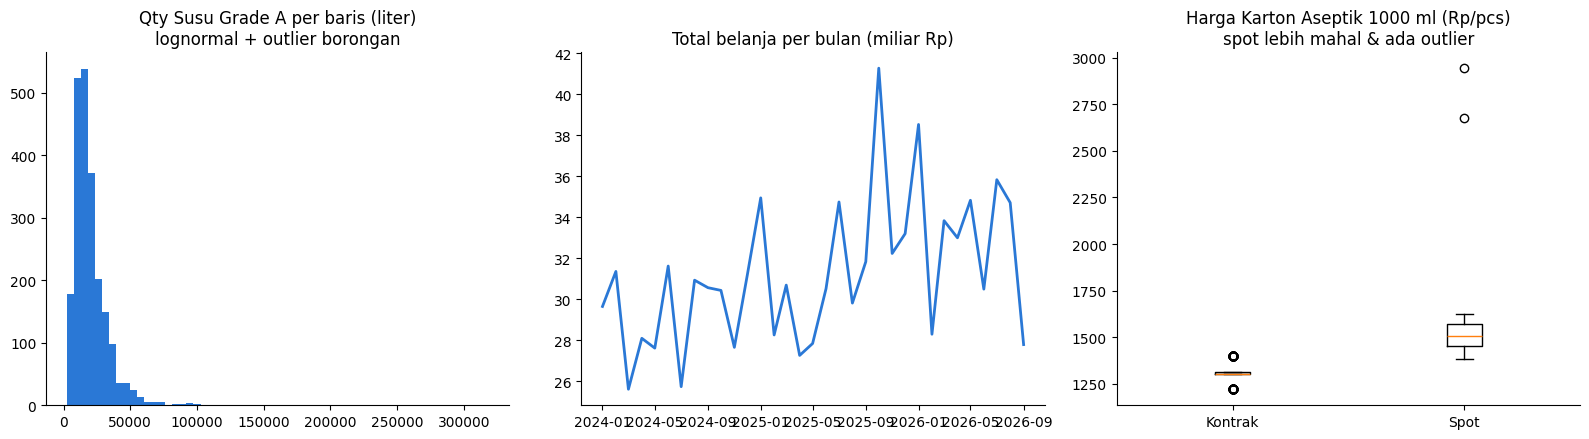

In [13]:
BIRU, ORANYE = '#2a78d6', '#eb6834'
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

susu = src_purchase_order[src_purchase_order.product_id == 'PRD-001']
ax[0].hist(susu.quantity_ordered, bins=60, color=BIRU)
ax[0].set_title('Qty Susu Grade A per baris (liter)\nlognormal + outlier borongan')

bulanan = src_purchase_order.groupby(src_purchase_order.po_date.dt.to_period('M')).net_amount.sum() / 1e9
ax[1].plot(bulanan.index.to_timestamp(), bulanan.values, color=BIRU, lw=2)
ax[1].set_title('Total belanja per bulan (miliar Rp)')

ax[2].boxplot([src_purchase_order.loc[src_purchase_order.contract_id.notna() & (src_purchase_order.product_id == 'PRD-010'), 'unit_price'],
               src_purchase_order.loc[src_purchase_order.contract_id.isna() & (src_purchase_order.product_id == 'PRD-010'), 'unit_price']],
              tick_labels=['Kontrak', 'Spot'])
ax[2].set_title('Harga Karton Aseptik 1000 ml (Rp/pcs)\nspot lebih mahal & ada outlier')
for a in ax:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('cek_distribusi.png', dpi=100); plt.show()

### 10d. Contoh skenario SCD di change log

In [14]:
src_change_log[src_change_log.column_name.isin(['vendor_name', 'city', 'province', 'vendor_category', 'product_category', 'end_date'])].head(12)

,log_id,table_name,record_id,column_name,old_value,new_value,changed_at,reason
0,LOG-00001,vendor,VND-002,vendor_name,KUD Sari Mulya Pangalengan,KUD Sari Mulya Pangalengan Bandung,2024-05-20,Koreksi nama badan usaha
1,LOG-00002,vendor,VND-013,vendor_name,PT Aseptika Kemasindo,PT Aseptika Kemasindo Tbk,2025-11-10,Perusahaan menjadi Tbk
12,LOG-00013,vendor,VND-005,city,Bandung Barat,Subang,2025-03-01,Relokasi peternakan
13,LOG-00014,vendor,VND-011,city,Rembang,Tuban,2025-08-15,Relokasi gudang
14,LOG-00015,vendor,VND-011,province,Jawa Tengah,Jawa Timur,2025-08-15,Relokasi gudang
15,LOG-00016,vendor,VND-012,vendor_category,Supplier Bahan Pangan,Supplier Kultur & Enzim,2025-06-01,Reklasifikasi vendor
17,LOG-00018,product,PRD-015,product_category,Material Kemasan,Bahan Pembantu,2025-04-01,Reklasifikasi kategori
54,LOG-00055,contract,CTR-2025-002,end_date,2025-12-31 00:00:00,2026-12-31 00:00:00,2025-12-05,Adendum perpanjangan kontrak
55,LOG-00056,contract,CTR-2025-004,end_date,2025-12-31 00:00:00,2026-06-30 00:00:00,2025-12-14,Adendum perpanjangan kontrak
56,LOG-00057,contract,CTR-2025-006,end_date,2025-12-31 00:00:00,2026-06-30 00:00:00,2025-12-20,Adendum perpanjangan kontrak
